In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("5x127x127_training_with_morphology.csv")

In [5]:
df.head()

,coord,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,g_isophotal_area,...,z_cmodel_magsigma,z_ellipticity,z_half_light_radius,z_isophotal_area,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index
0,"b'(179028.65625, 99644.3671875, -23767.86328125)'",-6.616883,1,1,1,20.162785,0.002381,0.026,2.085,177.0,...,0.002657,0.076,2.186,127.0,2.112,1.951,-8.0189,4.62,63.61,1.146
1,"b'(178895.09375, 99811.6484375, -24069.6933593...",-6.701294,1,1,1,20.320715,0.005252,0.143,5.986,327.0,...,0.002538,0.129,6.270,547.0,5.043,4.393,-7.6611,6.60,74.63,1.576
2,"b'(178918, 99992.578125, -23130.162109375)'",-6.438588,1,1,1,21.629736,0.013312,0.068,7.286,162.0,...,0.002606,0.082,6.687,611.0,5.370,4.932,-7.2715,7.26,83.77,2.096
3,"b'(179111.03125, 99659.84375, -23072.220703125)'",-6.422391,1,1,1,21.448307,0.004646,0.012,2.108,109.0,...,0.005510,0.023,2.966,121.0,2.323,2.269,-6.8408,6.60,29.82,1.943
4,"b'(178849.21875, 99990.828125, -23663.556640625)'",-6.587715,1,1,1,21.827169,0.010504,0.150,4.552,113.0,...,0.003021,0.256,5.264,401.0,4.652,3.463,-7.2982,7.26,66.69,2.187


# EDA

In [6]:
df.columns

Index(['coord', 'dec', 'g_central_image_pop_10px_rad',
       'g_central_image_pop_15px_rad', 'g_central_image_pop_5px_rad',
       'g_cmodel_mag', 'g_cmodel_magsigma', 'g_ellipticity',
       'g_half_light_radius', 'g_isophotal_area', 'g_major_axis',
       'g_minor_axis', 'g_peak_surface_brightness', 'g_petro_rad',
       'g_pos_angle', 'g_sersic_index', 'i_central_image_pop_10px_rad',
       'i_central_image_pop_15px_rad', 'i_central_image_pop_5px_rad',
       'i_cmodel_mag', 'i_cmodel_magsigma', 'i_ellipticity',
       'i_half_light_radius', 'i_isophotal_area', 'i_major_axis',
       'i_minor_axis', 'i_peak_surface_brightness', 'i_petro_rad',
       'i_pos_angle', 'i_sersic_index', 'object_id',
       'r_central_image_pop_10px_rad', 'r_central_image_pop_15px_rad',
       'r_central_image_pop_5px_rad', 'r_cmodel_mag', 'r_cmodel_magsigma',
       'r_ellipticity', 'r_half_light_radius', 'r_isophotal_area',
       'r_major_axis', 'r_minor_axis', 'r_peak_surface_brightness',
       'r_p

In [7]:
df.shape

(204573, 84)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204573 entries, 0 to 204572
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   coord                         204573 non-null  object 
 1   dec                           204573 non-null  float64
 2   g_central_image_pop_10px_rad  204573 non-null  int64  
 3   g_central_image_pop_15px_rad  204573 non-null  int64  
 4   g_central_image_pop_5px_rad   204573 non-null  int64  
 5   g_cmodel_mag                  204573 non-null  float64
 6   g_cmodel_magsigma             204573 non-null  float64
 7   g_ellipticity                 204573 non-null  float64
 8   g_half_light_radius           204573 non-null  float64
 9   g_isophotal_area              204573 non-null  float64
 10  g_major_axis                  204573 non-null  float64
 11  g_minor_axis                  204573 non-null  float64
 12  g_peak_surface_brightness     204573 non-nul

In [9]:
df.describe()

,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,g_isophotal_area,g_major_axis,...,z_cmodel_magsigma,z_ellipticity,z_half_light_radius,z_isophotal_area,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index
count,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,...,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000
mean,4.819285,1.015862,1.033543,0.998133,21.256327,0.009995,0.229963,6.508896,698.924804,5.528036,...,0.006686,0.231929,5.891219,803.493164,5.732100,4.060182,-6.812149,6.257465,1.829148,1.657161
std,14.836012,0.201299,0.242275,0.158129,1.888613,0.066851,0.171878,3.643963,912.827984,4.107583,...,0.033624,0.167484,3.168950,878.649336,3.687718,2.153258,1.429269,1.410914,52.351394,0.860905
min,-7.227071,0.000000,0.000000,0.000000,14.365486,0.000128,0.000000,-11.244000,0.000000,0.000000,...,0.000097,0.000000,0.000000,0.000000,0.000000,0.000000,-10.623000,0.000000,-90.000000,0.000000
25%,-0.963948,1.000000,1.000000,1.000000,19.719109,0.001517,0.094000,3.873000,121.000000,2.685000,...,0.000996,0.099000,3.678000,146.000000,2.827000,2.302000,-7.827900,5.280000,-43.810000,1.031000
50%,0.325055,1.000000,1.000000,1.000000,21.503017,0.004896,0.189000,5.667000,261.000000,3.917000,...,0.002083,0.195000,5.219000,491.000000,4.911000,3.726000,-6.994000,5.940000,3.600000,1.520000
75%,1.724730,1.000000,1.000000,1.000000,22.624615,0.011667,0.328000,7.991000,954.000000,7.273000,...,0.005968,0.326000,7.161000,1138.000000,7.514000,5.253000,-5.919700,6.600000,47.470000,2.093000
max,53.259826,3.000000,4.000000,3.000000,29.835554,28.564775,0.976000,42.020000,7530.000000,39.735000,...,12.755774,0.933000,40.717000,7534.000000,41.670000,16.890000,0.000000,10.560000,90.000000,9.915000


In [10]:
df.duplicated().sum()

0

In [11]:
df["specz_redshift"].describe()

count    204573.000000
mean          0.595007
std           0.572976
min           0.010100
25%           0.212570
50%           0.488950
75%           0.694360
max           3.997880
Name: specz_redshift, dtype: float64

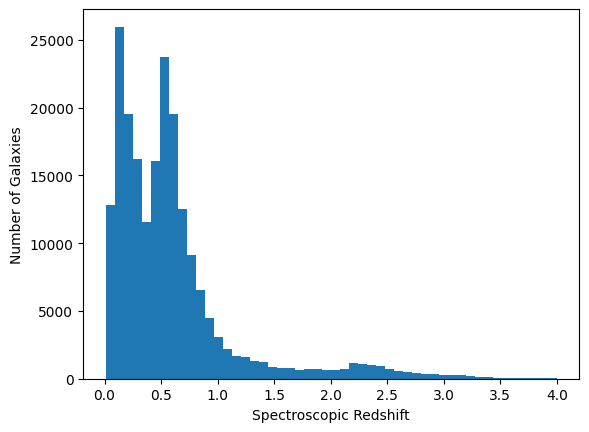

In [12]:
plt.hist(df["specz_redshift"], bins=50)
plt.xlabel("Spectroscopic Redshift")
plt.ylabel("Number of Galaxies")
plt.show()

In [13]:
features = [
    "g_cmodel_mag",
    "r_cmodel_mag",
    "i_cmodel_mag",
    "z_cmodel_mag",
    "y_cmodel_mag"
]

df[features].describe()


,g_cmodel_mag,r_cmodel_mag,i_cmodel_mag,z_cmodel_mag,y_cmodel_mag
count,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000
mean,21.256327,20.246424,19.633747,19.325146,19.153789
std,1.888613,1.880042,1.848060,1.848819,1.871167
min,14.365486,13.768898,13.376333,13.123674,12.939251
25%,19.719109,18.773922,18.263514,17.973379,17.789887
50%,21.503017,20.309673,19.507687,19.136146,18.939899
75%,22.624615,21.579090,20.993273,20.717060,20.572125
max,29.835554,30.006908,27.931854,28.985821,33.529446


In [14]:
features = [
    "g_cmodel_mag",
    "r_cmodel_mag",
    "i_cmodel_mag",
    "z_cmodel_mag",
    "y_cmodel_mag"
]

df[features + ["specz_redshift"]].corr()["specz_redshift"].sort_values()


g_cmodel_mag      0.365018
r_cmodel_mag      0.476916
i_cmodel_mag      0.526626
z_cmodel_mag      0.536351
y_cmodel_mag      0.542015
specz_redshift    1.000000
Name: specz_redshift, dtype: float64

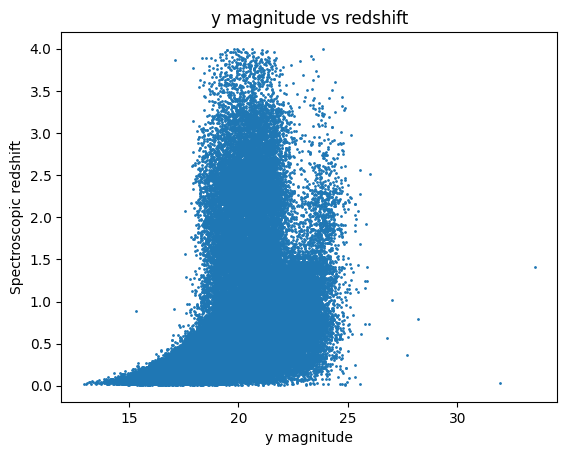

In [15]:
plt.scatter(
    df["y_cmodel_mag"],
    df["specz_redshift"],
    s=1
)

plt.xlabel("y magnitude")
plt.ylabel("Spectroscopic redshift")
plt.title("y magnitude vs redshift")
plt.show()